In [245]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [246]:
ecommerce_sales = pd.read_csv("ecommerce_sales.csv")
ecommerce_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          20000 non-null  int64  
 1   order_date        20000 non-null  object 
 2   customer_id       20000 non-null  int64  
 3   product_category  20000 non-null  object 
 4   region            20000 non-null  object 
 5   quantity          20000 non-null  int64  
 6   unit_price        20000 non-null  float64
 7   discount          20000 non-null  float64
 8   payment_method    20000 non-null  object 
 9   delivery_days     20000 non-null  int64  
 10  customer_rating   20000 non-null  float64
 11  revenue           20000 non-null  float64
dtypes: float64(4), int64(4), object(4)
memory usage: 1.8+ MB


In [247]:
ecommerce_sales[ecommerce_sales.duplicated()].head(10)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue


In [248]:
ecommerce_sales.drop_duplicates().shape

(20000, 12)

In [249]:
ecommerce_sales = ecommerce_sales.drop_duplicates()
ecommerce_sales.shape

(20000, 12)

In [250]:
ecommerce_sales.isnull().sum()


,0
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


In [251]:
#display the first five dataset
ecommerce_sales.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01 00:00:00,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02 00:00:00,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03 00:00:00,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04 00:00:00,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05 00:00:00,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [252]:
ecommerce_sales.shape

(20000, 12)

In [253]:
ecommerce_sales.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,20000.500000,1499.837800,3.997900,306.346178,0.176340,6.025400,2.985895,1007.520303
std,5773.647028,289.209739,2.007087,152.216288,0.100869,3.152357,1.358557,774.625901
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,15000.750000,1249.000000,2.000000,183.140000,0.090000,3.000000,2.000000,375.997500
50%,20000.500000,1500.000000,4.000000,313.090000,0.180000,6.000000,3.000000,809.635000
75%,25000.250000,1752.000000,6.000000,422.740000,0.260000,9.000000,4.000000,1471.277500
max,30000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [254]:
#find the item how many type it's sell

print("Product Categories:\n")
print(ecommerce_sales['product_category'].value_counts())

print("\nRegions:\n")
print(ecommerce_sales['region'].value_counts())

print("\nPayment Methods:\n")
print(ecommerce_sales['payment_method'].value_counts())


Product Categories:

product_category
Electronics    7113
Clothing       6205
Home           3812
Beauty         2870
Name: count, dtype: int64

Regions:

region
North    5140
West     5043
East     4932
South    4885
Name: count, dtype: int64

Payment Methods:

payment_method
Card      7315
COD       6786
Wallet    5899
Name: count, dtype: int64


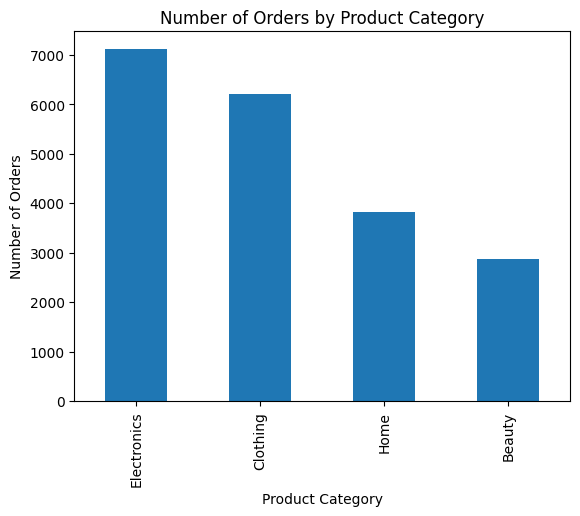

In [255]:
import matplotlib.pyplot as plt

ecommerce_sales['product_category'].value_counts().plot(kind='bar')

plt.title('Number of Orders by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Orders')
plt.show()

#“This bar chart shows the number of orders in each product category. Electronics has the highest number of orders, while Beauty has the lowest.”

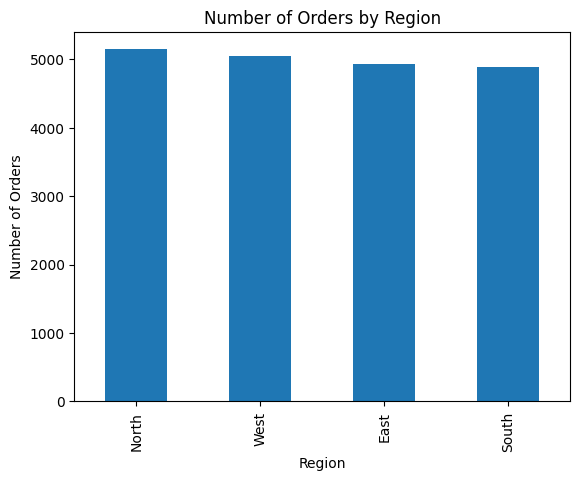

In [256]:
ecommerce_sales['region'].value_counts().plot(kind='bar')

plt.title('Number of Orders by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.show()

#“The order distribution is fairly balanced across the four regions. West has the highest number of orders, while South has the lowest.”

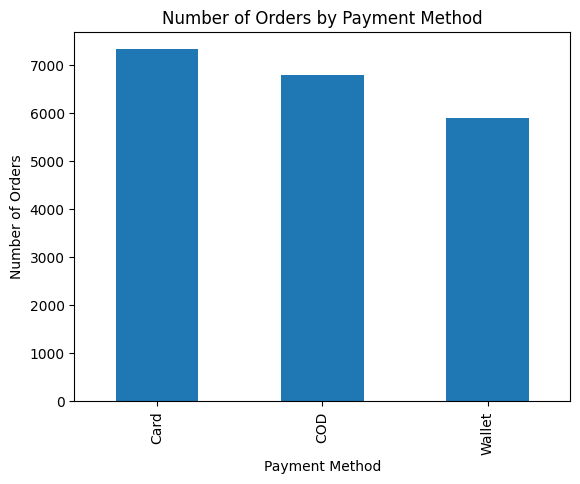

In [257]:
ecommerce_sales['payment_method'].value_counts().plot(kind='bar')

plt.title('Number of Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.show()

In [258]:
category_revenue = ecommerce_sales.groupby('product_category')['revenue'].sum()

print(category_revenue)



#“Electronics generates the highest total revenue, with approximately 1.83 million.”

product_category
Beauty         2255247.63
Clothing       5088984.98
Electronics    9240646.55
Home           3565526.90
Name: revenue, dtype: float64


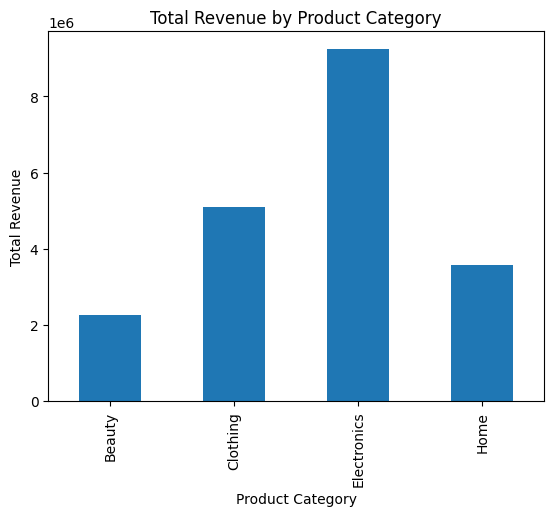

In [259]:
category_revenue.plot(kind='bar')

plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show()

In [260]:
#Average revenue per order
average_revenue = ecommerce_sales.groupby('product_category')['revenue'].mean()

print(average_revenue)

product_category
Beauty          785.800568
Clothing        820.142624
Electronics    1299.120842
Home            935.342838
Name: revenue, dtype: float64


In [261]:
#Total revenue tells us the overall contribution of a category, while average revenue tells us how much revenue an individual order generates on average

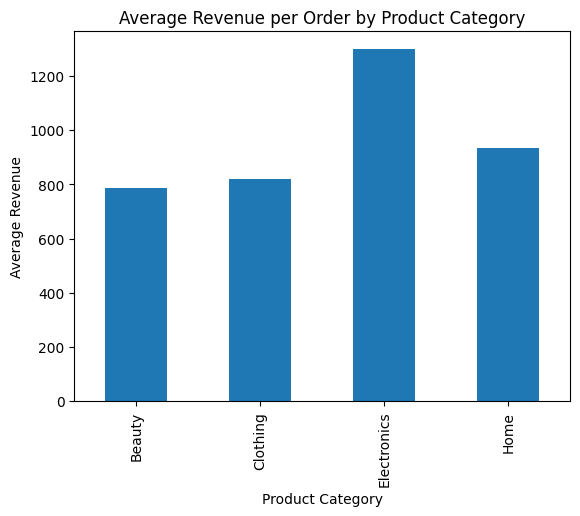

In [262]:
average_revenue.plot(kind='bar')

plt.title('Average Revenue per Order by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Revenue')
plt.show()

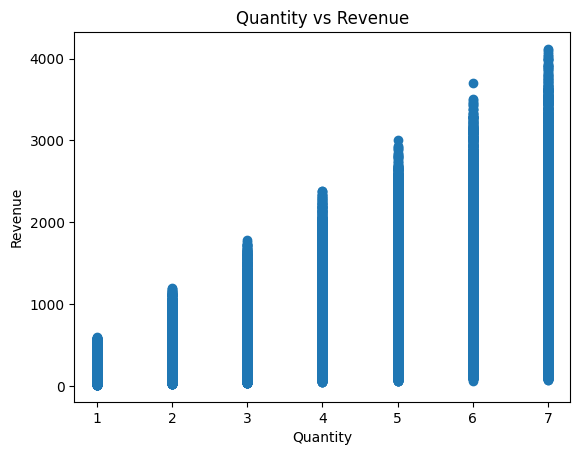

In [263]:
#Quantity vs Revenue

plt.scatter(ecommerce_sales['quantity'], ecommerce_sales['revenue'])

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

In [264]:
ecommerce_sales['quantity'].corr(ecommerce_sales['revenue'])


#When the quantity increases, revenue generally tends to increase as well.

np.float64(0.6525727282315511)

In [265]:
'''
But it is not 1.0, so quantity is not the only factor affecting revenue. Unit price and discount also influence revenue.

The correlation between quantity and revenue is 0.6235.., which indicates a moderately strong positive relationship. Higher quantities generally result in higher revenue, but other factors also affect revenue.”
'''

'\nBut it is not 1.0, so quantity is not the only factor affecting revenue. Unit price and discount also influence revenue.\n\nThe correlation between quantity and revenue is 0.6235.., which indicates a moderately strong positive relationship. Higher quantities generally result in higher revenue, but other factors also affect revenue.”\n'

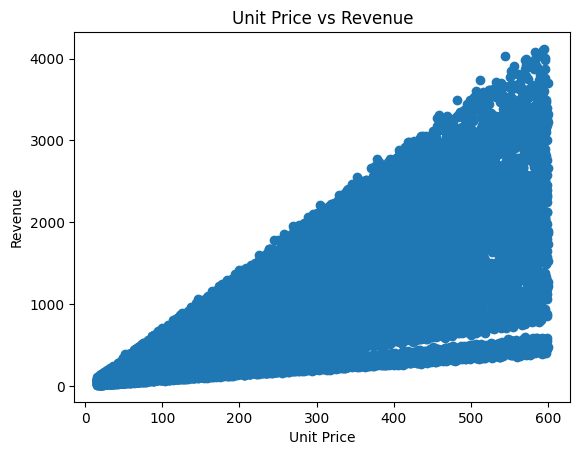

In [266]:
plt.scatter(ecommerce_sales['unit_price'], ecommerce_sales['revenue'])

plt.title('Unit Price vs Revenue')
plt.xlabel('Unit Price')
plt.ylabel('Revenue')
plt.show()

In [267]:
'''
There is a strong positive relationship between unit_price and revenue.

As the unit price increases, the possible revenue values generally increase.

But notice the points become more spread out at higher prices. That's because revenue depends on multiple factors, especially quantity and discount.
'''

"\nThere is a strong positive relationship between unit_price and revenue.\n\nAs the unit price increases, the possible revenue values generally increase.\n\nBut notice the points become more spread out at higher prices. That's because revenue depends on multiple factors, especially quantity and discount.\n"

In [268]:
ecommerce_sales['unit_price'].corr(ecommerce_sales['revenue'])

np.float64(0.6456629946822733)

In [269]:
'''
“Unit price has the stronger correlation with revenue, with a correlation of approximately 0.678, compared with 0.624 for quantity.”
correlation does not prove causation.
'''


'\n“Unit price has the stronger correlation with revenue, with a correlation of approximately 0.678, compared with 0.624 for quantity.”\ncorrelation does not prove causation.\n'

In [270]:
ecommerce_sales['discount'].corr(ecommerce_sales['revenue'])

np.float64(-0.17219062934753757)

In [271]:
'''
“Unit price has the strongest positive correlation with revenue at approximately 0.678. Quantity also has a positive correlation of approximately 0.624. Discount has a weak negative correlation of approximately -0.139.
'''

'\n“Unit price has the strongest positive correlation with revenue at approximately 0.678. Quantity also has a positive correlation of approximately 0.624. Discount has a weak negative correlation of approximately -0.139.\n'

In [272]:
ecommerce_sales.groupby('product_category')[
    ['quantity', 'unit_price', 'discount', 'delivery_days',
     'customer_rating', 'revenue']
].mean()

,quantity,unit_price,discount,delivery_days,customer_rating,revenue
product_category,,,,,,
Beauty,4.041812,235.302178,0.178460,6.110801,3.000174,785.800568
Clothing,3.995165,250.182616,0.177318,5.988396,2.992232,820.142624
Electronics,3.974554,396.258099,0.174814,6.029945,2.966835,1299.120842
Home,4.012854,283.483555,0.175997,6.012854,3.000393,935.342838


In [273]:
ecommerce_sales['product_category'].value_counts(normalize=True) * 100


,proportion
product_category,
Electronics,35.565
Clothing,31.025
Home,19.060
Beauty,14.350


In [274]:
ecommerce_sales['order_date'] = pd.to_datetime(
    ecommerce_sales['order_date'],
    format='mixed'
)

In [275]:
ecommerce_sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          20000 non-null  int64         
 1   order_date        20000 non-null  datetime64[ns]
 2   customer_id       20000 non-null  int64         
 3   product_category  20000 non-null  object        
 4   region            20000 non-null  object        
 5   quantity          20000 non-null  int64         
 6   unit_price        20000 non-null  float64       
 7   discount          20000 non-null  float64       
 8   payment_method    20000 non-null  object        
 9   delivery_days     20000 non-null  int64         
 10  customer_rating   20000 non-null  float64       
 11  revenue           20000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 1.8+ MB


In [276]:
print("Start date:", ecommerce_sales['order_date'].min())
print("End date:", ecommerce_sales['order_date'].max())

Start date: 2022-01-01 00:00:00
End date: 2035-09-09 00:00:00


In [277]:
yearly_revenue = ecommerce_sales.groupby(
    ecommerce_sales['order_date'].dt.year
)['revenue'].sum()

print(yearly_revenue)

order_date
2022    1439118.05
2023    1507641.24
2024    1469897.65
2025    1498344.68
2026    1527945.14
2027    1494637.68
2028    1470058.37
2029    1437436.04
2030    1423984.09
2031    1432365.85
2032    1491415.60
2033    1499639.73
2034    1476407.44
2035     981514.50
Name: revenue, dtype: float64


In [278]:
#@title Understand what we're predicting
'''
“Based on the other information about an order, can we predict whether the product belongs to Beauty, Clothing, Electronics, or Home?” '''

'\n“Based on the other information about an order, can we predict whether the product belongs to Beauty, Clothing, Electronics, or Home?” '

In [279]:
X = ecommerce_sales[
    ['quantity',
     'unit_price',
     'discount',
     'delivery_days',
     'customer_rating',
     'revenue']
]

y = ecommerce_sales['product_category']

In [280]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 6)
y shape: (20000,)


In [281]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,
                                                    stratify=y
)

In [282]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16000, 6)
X_test: (4000, 6)
y_train: (16000,)
y_test: (4000,)


In [283]:
"""
Stratify:

“Because the target classes are somewhat imbalanced, stratification keeps a similar class distribution in both the training and testing datasets.”
"""

'\nStratify:\n\n“Because the target classes are somewhat imbalanced, stratification keeps a similar class distribution in both the training and testing datasets.”\n'

In [284]:
from sklearn.preprocessing import StandardScaler  #It puts all our numerical features onto a similar scale.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [285]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(16000, 6)
(4000, 6)


In [286]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.4635


In [287]:
print(pd.Series(y_pred).value_counts())

Electronics    2031
Clothing       1969
Name: count, dtype: int64


In [288]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[   0  399  175    0]
 [   0  790  451    0]
 [   0  359 1064    0]
 [   0  421  341    0]]


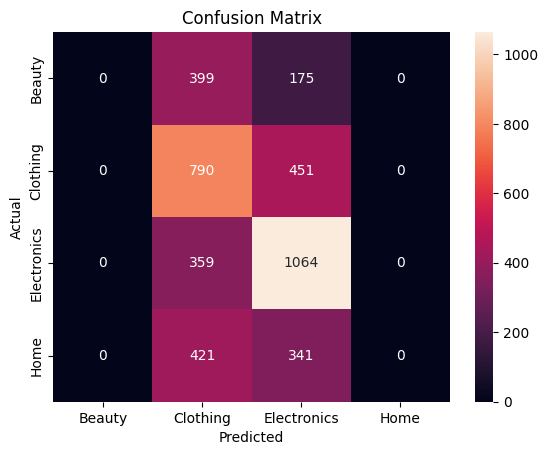

In [289]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [290]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.4635

Confusion Matrix:
[[   0  399  175    0]
 [   0  790  451    0]
 [   0  359 1064    0]
 [   0  421  341    0]]

Classification Report:
              precision    recall  f1-score   support

      Beauty       0.00      0.00      0.00       574
    Clothing       0.40      0.64      0.49      1241
 Electronics       0.52      0.75      0.62      1423
        Home       0.00      0.00      0.00       762

    accuracy                           0.46      4000
   macro avg       0.23      0.35      0.28      4000
weighted avg       0.31      0.46      0.37      4000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


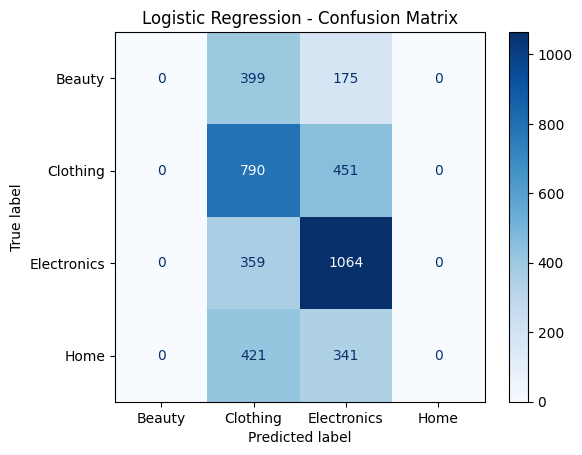

In [291]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [292]:
# Feature importance for Logistic Regression

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
5          revenue    0.098435
2         discount    0.022013
3    delivery_days    0.016455
4  customer_rating    0.013668
0         quantity   -0.043016
1       unit_price   -0.511182


In [299]:
# Test the model with a new order

new_order = [[
    2,       # quantity
    1,     # unit_price
    0.50,    # discount
    5,       # delivery_days
    4,       # customer_rating
    140     # revenue
]]

# Scale the new input
new_order_scaled = scaler.transform(new_order)

# Make prediction
prediction = model.predict(new_order_scaled)

print("Predicted Product Category:", prediction[0])

Predicted Product Category: Clothing


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [303]:
# Simple Product Category Prediction

quantity = float(input("Enter quantity: "))
unit_price = float(input("Enter unit price: "))
discount = float(input("Enter discount (e.g. 0.10 for 10%): "))
delivery_days = float(input("Enter delivery days: "))
customer_rating = float(input("Enter customer rating (1-5): "))
revenue = float(input("Enter revenue: "))

# Create input
new_order = [[
    quantity,
    unit_price,
    discount,
    delivery_days,
    customer_rating,
    revenue
]]

# Scale the input using the same scaler used during training
new_order_scaled = scaler.transform(new_order)

# Predict category
prediction = model.predict(new_order_scaled)

print("\n==============================")
print(" Predicted Product Category")
print("==============================")
print(prediction[0])

Enter quantity: 2
Enter unit price: 150
Enter discount (e.g. 0.10 for 10%): 0.1
Enter delivery days: 4
Enter customer rating (1-5): 5
Enter revenue: 270

 Predicted Product Category
Clothing


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
